# FA20DIT Drive Health Report v1

Simple telemetry pipeline for OBD Fusion and Cobb Accessport CSV logs.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.append(str(ROOT / 'src'))

from vehicle_telemetry.io import read_log_csv
from vehicle_telemetry.normalize import normalize_log
from vehicle_telemetry.features import add_derived_features
from vehicle_telemetry.plots import (
    plot_rpm_load_heatmap,
    plot_load_map_over_time,
    plot_fuel_trims,
    plot_temps,
    plot_accel_maf_vs_rpm,
)
from vehicle_telemetry.report import build_summary, build_flags

In [2]:
# Pick one log file to analyze
log_path = ROOT / 'data' / 'datalog4.csv'

raw_df, log_type = read_log_csv(log_path)
norm_df = normalize_log(raw_df, log_type=log_type)
feat_df = add_derived_features(norm_df)

print(f'Log: {log_path.name}')
print(f'Detected type: {log_type}')
print(f'Rows: {len(feat_df):,}')
feat_df.head()

Log: datalog4.csv
Detected type: cobb_accessport
Rows: 8,308


,time_s,rpm,speed_kph,throttle_pct,maf_gps,map_kpa,coolant_c,iat_c,stft_pct,ltft_pct,...,dam,fbk,fkl,boost_target_kpa,boost_error_kpa,wgdc_pct,speed_mph,dt_s,load_proxy,state
0,0.000,1798,0.0,8.7,7.36,24.683231,37.0,30.0,-11.72,7.81,...,0.75,0.0,0.0,-69.016521,7.446338,0.0,0.0,0.069,4.093437,idle
1,0.026,1798,0.0,8.7,7.37,24.683231,37.0,30.0,-11.72,7.81,...,0.75,0.0,0.0,-69.016521,7.446338,0.0,0.0,0.026,4.098999,idle
2,0.122,1799,0.0,8.7,7.37,24.407441,37.0,30.0,-11.72,7.81,...,0.75,0.0,0.0,-69.016521,7.446338,0.0,0.0,0.096,4.096720,idle
3,0.221,1799,0.0,8.7,7.38,24.545336,37.0,30.0,-11.72,7.81,...,0.75,0.0,0.0,-69.016521,7.515285,0.0,0.0,0.099,4.102279,idle
4,0.275,1800,0.0,8.7,7.37,24.545336,37.0,30.0,-11.72,7.81,...,0.75,0.0,0.0,-69.016521,7.515285,0.0,0.0,0.054,4.094444,idle


In [3]:
summary = build_summary(feat_df)
flags = build_flags(summary)

summary_df = pd.DataFrame([summary]).T.rename(columns={0: 'value'})
flag_df = pd.DataFrame([flags]).T.rename(columns={0: 'flagged'})

print('Summary Metrics')
display(summary_df)
print('Basic Flags')
display(flag_df)

Summary Metrics


,value
duration_s,568.435000
avg_rpm,2243.405272
avg_speed_mph,15.260953
avg_load_proxy,5.132743
stft_mean_pct,-2.081178
ltft_mean_pct,8.168836
coolant_max_c,92.000000
iat_max_c,31.000000
dam_min,0.750000
fbk_min,-2.810000


Basic Flags


,flagged
fuel_trim_bias,True
active_knock,True
historical_knock,True
high_coolant,False
high_iat,False
boost_control_variance,True


DAM Analysis
------------
Minimum DAM: 0.75
Final DAM: 0.75

Interpretation:
The ECU maintained reduced ignition advance margin during the drive.
No recovery to full confidence was observed.
Further analysis of FBK/FKL is required to determine whether knock occurred.


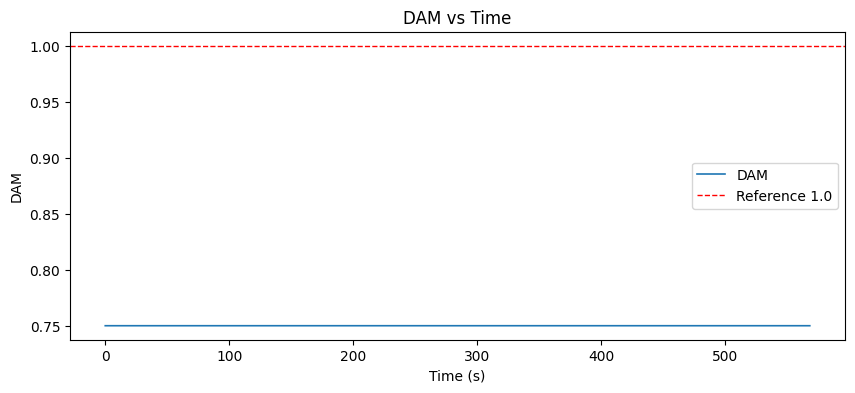

In [4]:
dam_series = pd.to_numeric(feat_df.get('dam'), errors='coerce')
dam_valid = dam_series.dropna()

if dam_valid.empty:
    initial_dam = float('nan')
    min_dam = float('nan')
    final_dam = float('nan')
    dam_change = float('nan')
    pct_below_one = float('nan')
    interpretation = (
        'Interpretation:\n'
        'No DAM data available in this log.'
    )
else:
    initial_dam = float(dam_valid.iloc[0])
    min_dam = float(dam_valid.min())
    final_dam = float(dam_valid.iloc[-1])
    dam_change = final_dam - initial_dam
    pct_below_one = float((dam_valid < 1.0).mean() * 100.0)

    interpretation = (
        'Interpretation:\n'
        'The ECU maintained reduced ignition advance margin during the drive.\n'
        'No recovery to full confidence was observed.\n'
        'Further analysis of FBK/FKL is required to determine whether knock occurred.'
    )

print('DAM Analysis')
print('------------')
print(f'Minimum DAM: {min_dam:.2f}' if pd.notna(min_dam) else 'Minimum DAM: n/a')
print(f'Final DAM: {final_dam:.2f}' if pd.notna(final_dam) else 'Final DAM: n/a')
print('')
print(interpretation)

fig, ax = plt.subplots(figsize=(10, 4))
if 'time_s' in feat_df.columns and not dam_valid.empty:
    ax.plot(feat_df['time_s'], dam_series, lw=1.2, label='DAM')
    ax.axhline(1.0, color='red', ls='--', lw=1.0, label='Reference 1.0')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('DAM')
    ax.set_title('DAM vs Time')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Need time_s and DAM data', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()
plt.show()

## DAM Analysis

DAM (Dynamic Advance Multiplier) represents ECU confidence in knock-free ignition timing operation on Subaru ECUs. When DAM is near 1.0, the ECU is generally confident in applying normal learned timing advance. When DAM drops below 1.0, it indicates the ECU has reduced ignition timing authority for knock safety.

FBK Analysis
------------
Minimum FBK: -2.81
Samples with FBK <= -2.0: 4
Samples with FBK <= -3.0: 0


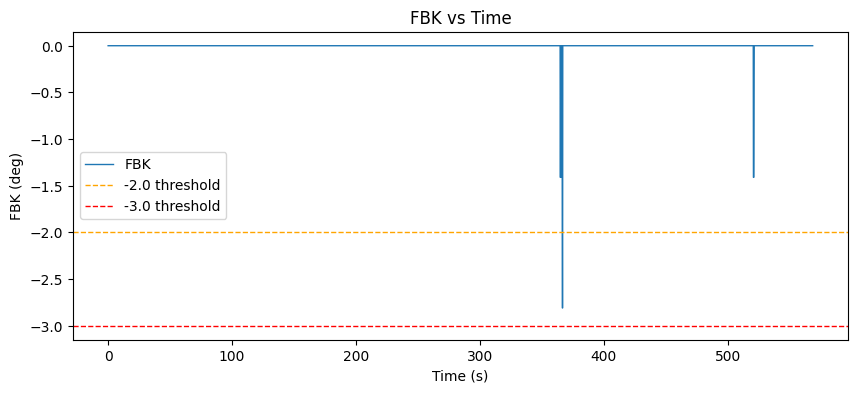

Interpretation:
Meaningful FBK knock events occurred (FBK <= -2.0) but none reached -3.0.


In [5]:
fbk = pd.to_numeric(feat_df.get('fbk'), errors='coerce')
fbk_valid = fbk.dropna()

if fbk_valid.empty:
    fbk_min = float('nan')
    fbk_le_2 = 0
    fbk_le_3 = 0
else:
    fbk_min = float(fbk_valid.min())
    fbk_le_2 = int((fbk_valid <= -2.0).sum())
    fbk_le_3 = int((fbk_valid <= -3.0).sum())

print('FBK Analysis')
print('------------')
print(f'Minimum FBK: {fbk_min:.2f}' if pd.notna(fbk_min) else 'Minimum FBK: n/a')
print(f'Samples with FBK <= -2.0: {fbk_le_2}')
print(f'Samples with FBK <= -3.0: {fbk_le_3}')

fig, ax = plt.subplots(figsize=(10, 4))
if not fbk_valid.empty and 'time_s' in feat_df.columns:
    ax.plot(feat_df['time_s'], fbk, lw=1.0, label='FBK')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('FBK (deg)')
    ax.set_title('FBK vs Time')
    ax.axhline(-2.0, color='orange', ls='--', lw=1.0, label='-2.0 threshold')
    ax.axhline(-3.0, color='red', ls='--', lw=1.0, label='-3.0 threshold')
    ax.legend()
elif not fbk_valid.empty and 'rpm' in feat_df.columns:
    ax.scatter(feat_df['rpm'], fbk, s=8, alpha=0.4)
    ax.set_xlabel('RPM')
    ax.set_ylabel('FBK (deg)')
    ax.set_title('FBK vs RPM')
else:
    ax.text(0.5, 0.5, 'Need FBK data and time_s or rpm', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()
plt.show()

if fbk_valid.empty:
    interpretation = 'No FBK data available in this log.'
elif fbk_le_3 > 0:
    interpretation = 'Meaningful FBK knock events occurred, including severe events (FBK <= -3.0).'
elif fbk_le_2 > 0:
    interpretation = 'Meaningful FBK knock events occurred (FBK <= -2.0) but none reached -3.0.'
else:
    interpretation = 'No meaningful FBK knock events were observed during this drive.'

print('Interpretation:')
print(interpretation)

## Feedback Knock (FBK) Analysis

Feedback Knock (FBK) is an immediate ignition timing correction applied by the ECU when knock is detected in the current operating condition. More negative FBK values indicate stronger short-term timing pull in response to potential knock events.

FKL Analysis


,metric,value
0,minimum FKL,-1.05
1,samples where FKL < 0,74.00
2,samples where FKL <= -1.4,0.00
3,samples where FKL <= -2.8,0.00


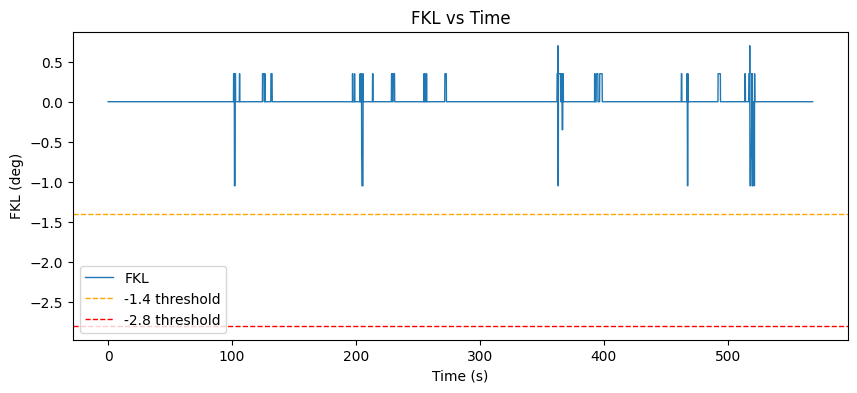

Interpretation:
Very small learned knock corrections were observed but never exceeded -1.4 deg. No meaningful persistent knock correction was detected during this drive.


In [6]:
fkl = pd.to_numeric(feat_df.get('fkl'), errors='coerce')
fkl_valid = fkl.dropna()

if fkl_valid.empty:
    fkl_min = float('nan')
    fkl_lt_0 = 0
    fkl_le_1_4 = 0
    fkl_le_2_8 = 0
else:
    fkl_min = float(fkl_valid.min())
    fkl_lt_0 = int((fkl_valid < 0).sum())
    fkl_le_1_4 = int((fkl_valid <= -1.4).sum())
    fkl_le_2_8 = int((fkl_valid <= -2.8).sum())

fkl_table = pd.DataFrame({
    'metric': [
        'minimum FKL',
        'samples where FKL < 0',
        'samples where FKL <= -1.4',
        'samples where FKL <= -2.8',
    ],
    'value': [fkl_min, fkl_lt_0, fkl_le_1_4, fkl_le_2_8],
})

print('FKL Analysis')
display(fkl_table)

fig, ax = plt.subplots(figsize=(10, 4))
if not fkl_valid.empty and 'time_s' in feat_df.columns:
    ax.plot(feat_df['time_s'], fkl, lw=1.0, label='FKL')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('FKL (deg)')
    ax.set_title('FKL vs Time')
    ax.axhline(-1.4, color='orange', ls='--', lw=1.0, label='-1.4 threshold')
    ax.axhline(-2.8, color='red', ls='--', lw=1.0, label='-2.8 threshold')
    ax.legend()
elif not fkl_valid.empty and 'rpm' in feat_df.columns:
    ax.scatter(feat_df['rpm'], fkl, s=8, alpha=0.4)
    ax.set_xlabel('RPM')
    ax.set_ylabel('FKL (deg)')
    ax.set_title('FKL vs RPM')
else:
    ax.text(0.5, 0.5, 'Need FKL data and time_s or rpm', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()
plt.show()

if fkl_valid.empty:
    fkl_interp = 'No FKL data available in this log.'
elif fkl_lt_0 == 0:
    fkl_interp = 'No learned knock correction was observed during this drive. FKL remained at or above 0.0 throughout the log.'
elif fkl_le_2_8 > 0 or fkl_le_1_4 >= 3:
    fkl_interp = 'Persistent learned knock correction was detected (including deeper negative FKL regions), which suggests repeated knock tendency in specific load/RPM areas.'
else:
    fkl_interp = 'Very small learned knock corrections were observed but never exceeded -1.4 deg. No meaningful persistent knock correction was detected during this drive.'

print('Interpretation:')
print(fkl_interp)

## FKL Analysis

FKL (Fine Knock Learn) is the ECU's learned, cell-based ignition correction over time. Unlike FBK, which is immediate/instant timing pull for current knock detection, FKL reflects retained learned correction in specific load/RPM regions, indicating repeated knock tendency in those areas.

Engine Stress Analysis


,metric,value
0,maximum load_proxy,37.435744
1,p95 load_proxy,13.294172
2,maximum maf_gps,128.860000
3,p95 maf_gps,41.095000
4,maximum map_kpa,189.950563
5,total time under high load (s),28.484000
6,percentage of drive under high load (%),5.010343


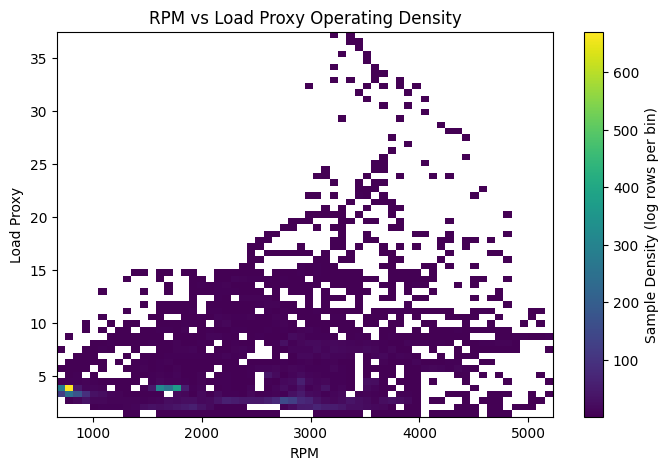

Interpretation:
Drive profile indicates moderate load operation. About 5.0% of drive time exceeded high-load threshold, with p95 load_proxy 13.3, peak load_proxy 37.4, and peak MAF 128.9 g/s. This suggests occasional stronger acceleration events without prolonged high-stress operation.


In [7]:
load = pd.to_numeric(feat_df.get('load_proxy'), errors='coerce')
maf = pd.to_numeric(feat_df.get('maf_gps'), errors='coerce')
map_kpa = pd.to_numeric(feat_df.get('map_kpa'), errors='coerce')
dt = pd.to_numeric(feat_df.get('dt_s'), errors='coerce').fillna(0.0)

load_valid = load.dropna()
maf_valid = maf.dropna()
map_valid = map_kpa.dropna()

max_load = float(load_valid.max()) if not load_valid.empty else float('nan')
p95_load = float(load_valid.quantile(0.95)) if not load_valid.empty else float('nan')
max_maf = float(maf_valid.max()) if not maf_valid.empty else float('nan')
p95_maf = float(maf_valid.quantile(0.95)) if not maf_valid.empty else float('nan')
max_map = float(map_valid.max()) if not map_valid.empty else float('nan')

high_load = (load > p95_load) if pd.notna(p95_load) else pd.Series(False, index=feat_df.index)
high_load_time_s = float(dt.where(high_load, 0.0).sum())
total_drive_time_s = float(dt.sum())
pct_high_load = (high_load_time_s / total_drive_time_s * 100.0) if total_drive_time_s > 0 else float('nan')

stress_table = pd.DataFrame({
    'metric': [
        'maximum load_proxy',
        'p95 load_proxy',
        'maximum maf_gps',
        'p95 maf_gps',
        'maximum map_kpa',
        'total time under high load (s)',
        'percentage of drive under high load (%)',
    ],
    'value': [max_load, p95_load, max_maf, p95_maf, max_map, high_load_time_s, pct_high_load],
})

print('Engine Stress Analysis')
display(stress_table)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
rpm = pd.to_numeric(feat_df.get('rpm'), errors='coerce')
heat_df = pd.DataFrame({'rpm': rpm, 'load_proxy': load}).dropna()
if heat_df.empty:
    ax.text(0.5, 0.5, 'Need rpm and load_proxy', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()
else:
    h = ax.hist2d(heat_df['rpm'], heat_df['load_proxy'], bins=60, cmap='viridis', cmin=1)
    plt.colorbar(h[3], ax=ax, label='Sample Density (log rows per bin)')
    ax.set_xlabel('RPM')
    ax.set_ylabel('Load Proxy')
    ax.set_title('RPM vs Load Proxy Operating Density')
plt.show()

if pd.isna(pct_high_load) or (pd.isna(max_load) and pd.isna(max_maf)):
    stress_interp = (
        'Insufficient data to classify engine stress for this drive. '
        'Check that load_proxy, maf_gps, map_kpa, and dt_s are populated.'
    )
elif pct_high_load < 5 and max_load < 60 and max_maf < 120:
    stress_interp = (
        'Drive profile indicates mostly light cruising. '
        f'Only {pct_high_load:.1f}% of sampled time was above high-load threshold, '
        f'with peak load_proxy {max_load:.1f} and peak MAF {max_maf:.1f} g/s. '
        'Engine operation was predominantly low demand with minimal sustained stress.'
    )
elif pct_high_load < 15 and max_load < 120 and max_maf < 220:
    stress_interp = (
        'Drive profile indicates moderate load operation. '
        f'About {pct_high_load:.1f}% of drive time exceeded high-load threshold, '
        f'with p95 load_proxy {p95_load:.1f}, peak load_proxy {max_load:.1f}, and peak MAF {max_maf:.1f} g/s. '
        'This suggests occasional stronger acceleration events without prolonged high-stress operation.'
    )
else:
    stress_interp = (
        'Drive profile indicates high stress engine operation. '
        f'High-load exposure reached {pct_high_load:.1f}% of drive time with peak load_proxy {max_load:.1f}, '
        f'p95 load_proxy {p95_load:.1f}, peak MAF {max_maf:.1f} g/s, and max MAP {max_map:.1f} kPa. '
        'This pattern is consistent with repeated or sustained heavy throttle/boost demand.'
    )

print('Interpretation:')
print(stress_interp)


## Engine Stress Analysis

This section summarizes engine load intensity using `load_proxy`, `maf_gps`, and `map_kpa`, then quantifies time spent above the 95th percentile load threshold to estimate how demanding the drive was on the engine.

`load_proxy` is calculated as: `load_proxy = maf_gps / rpm * 1000`

This proxy approximates airflow-per-revolution demand, which is useful for comparing relative engine stress across different RPM ranges.

Knock Context Analysis
Meaningful FBK events are defined as FBK <= -2.0


,time_s,rpm,load_proxy,map_kpa,throttle_pct,iat_c,state
5357,366.451,3134,24.428845,131.896707,33.1,26.0,cruise
5358,366.525,3138,24.668579,131.276179,31.5,26.0,cruise
5359,366.591,3150,24.117460,131.689864,28.3,26.0,cruise
5360,366.662,3194,23.130870,125.139845,27.6,26.0,cruise


,metric,value
0,count meaningful FBK events during accel/high-...,4.00
1,count meaningful FBK events outside accel/high...,0.00
2,minimum FBK during high-load conditions,-2.81
3,minimum FBK overall,-2.81


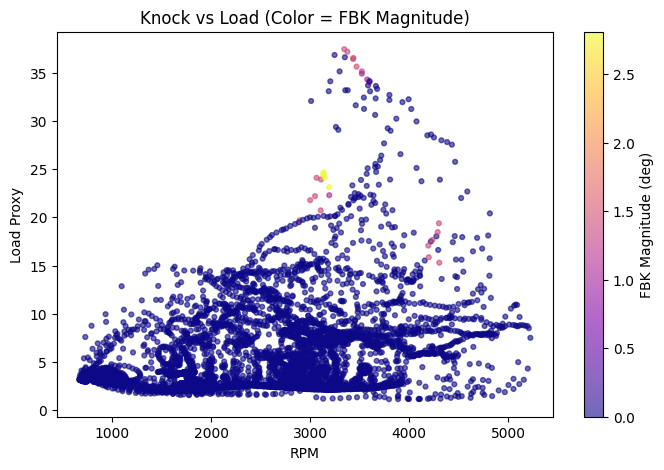

Interpretation:
Meaningful FBK corrections occurred mainly under accel/high-load conditions, which is more consistent with load-related knock sensitivity.


In [8]:
fbk = pd.to_numeric(feat_df.get('fbk'), errors='coerce')
rpm = pd.to_numeric(feat_df.get('rpm'), errors='coerce')
load_proxy = pd.to_numeric(feat_df.get('load_proxy'), errors='coerce')
map_kpa = pd.to_numeric(feat_df.get('map_kpa'), errors='coerce')
throttle = pd.to_numeric(feat_df.get('throttle_pct'), errors='coerce')
iat = pd.to_numeric(feat_df.get('iat_c'), errors='coerce')
time_s = pd.to_numeric(feat_df.get('time_s'), errors='coerce')
state = feat_df.get('state')
if state is None:
    state = pd.Series(['unknown'] * len(feat_df), index=feat_df.index)

event_mask = fbk <= -2.0
high_load_mask = ((throttle > 25.0) & (rpm > 2000.0)) | state.astype(str).str.lower().eq('accel')

events = pd.DataFrame({
    'time_s': time_s,
    'rpm': rpm,
    'load_proxy': load_proxy,
    'map_kpa': map_kpa,
    'throttle_pct': throttle,
    'iat_c': iat,
    'state': state,
    'fbk': fbk,
})[event_mask].copy()

events_table = events[['time_s', 'rpm', 'load_proxy', 'map_kpa', 'throttle_pct', 'iat_c', 'state']].copy()

event_count_high_load = int((event_mask & high_load_mask).sum())
event_count_outside_high_load = int((event_mask & (~high_load_mask)).sum())
min_fbk_high_load = fbk.where(high_load_mask).min()
min_fbk_overall = fbk.min()

print('Knock Context Analysis')
print('Meaningful FBK events are defined as FBK <= -2.0')
display(events_table)

context_summary = pd.DataFrame({
    'metric': [
        'count meaningful FBK events during accel/high-load',
        'count meaningful FBK events outside accel/high-load',
        'minimum FBK during high-load conditions',
        'minimum FBK overall',
    ],
    'value': [
        event_count_high_load,
        event_count_outside_high_load,
        float(min_fbk_high_load) if pd.notna(min_fbk_high_load) else float('nan'),
        float(min_fbk_overall) if pd.notna(min_fbk_overall) else float('nan'),
    ],
})
display(context_summary)

total_events = int(event_mask.sum())
if total_events == 0:
    context_interp = 'No meaningful FBK corrections (<= -2.0) were observed in this drive.'
elif event_count_high_load > event_count_outside_high_load:
    context_interp = (
        'Meaningful FBK corrections occurred mainly under accel/high-load conditions, '
        'which is more consistent with load-related knock sensitivity.'
    )
elif event_count_high_load < event_count_outside_high_load:
    context_interp = (
        'Meaningful FBK corrections occurred mostly outside accel/high-load operation, '
        'suggesting transient or non-peak-load knock correction behavior.'
    )
else:
    context_interp = (
        'Meaningful FBK corrections were split similarly between high-load and non-high-load operation.'
    )


# Knock vs load plot: X=RPM, Y=load_proxy, color=FBK magnitude
plot_df = pd.DataFrame({
    'rpm': rpm,
    'load_proxy': load_proxy,
    'fbk_mag': fbk.abs(),
}).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
if plot_df.empty:
    ax.text(0.5, 0.5, 'Need rpm, load_proxy, and FBK data', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()
else:
    sc = ax.scatter(plot_df['rpm'], plot_df['load_proxy'], c=plot_df['fbk_mag'], s=12, alpha=0.6, cmap='plasma')
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label('FBK Magnitude (deg)')
    ax.set_xlabel('RPM')
    ax.set_ylabel('Load Proxy')
    ax.set_title('Knock vs Load (Color = FBK Magnitude)')
plt.show()

print('Interpretation:')
print(context_interp)

## Knock Context Analysis

This section contextualizes meaningful FBK corrections (`FBK <= -2.0`) against engine operating conditions to determine whether knock timing pull is primarily load-driven (accel/high-load) or occurring outside heavy demand.